# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.

In [57]:
! git clone "https://github.com/isaactabor21/linearModels"

fatal: destination path 'linearModels' already exists and is not an empty directory.


In [58]:
import pandas as pd
data = pd.read_csv("/content/linearModels/data/cars_hw.csv")
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         976 non-null    int64 
 1   Make               976 non-null    object
 2   Make_Year          976 non-null    int64 
 3   Color              976 non-null    object
 4   Body_Type          976 non-null    object
 5   Mileage_Run        976 non-null    int64 
 6   No_of_Owners       976 non-null    object
 7   Seating_Capacity   976 non-null    int64 
 8   Fuel_Type          976 non-null    object
 9   Transmission       976 non-null    object
 10  Transmission_Type  976 non-null    object
 11  Price              976 non-null    int64 
dtypes: int64(5), object(7)
memory usage: 91.6+ KB
None


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


* The data has 976 entries.
* There are 12 columns, but we need to drop Unnamed: 0, so 11 true variables.
* Numeric variables appear to be correctly numeric.

In [59]:
data.drop(columns=['Unnamed: 0'], inplace=True)

2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.

In [60]:
transformed_variables = pd.get_dummies(data, columns=data.select_dtypes(include='object').columns, dtype='int', drop_first=True)
transformed_variables.head()

,Make_Year,Mileage_Run,Seating_Capacity,Price,Make_Datsun,Make_Ford,Make_Honda,Make_Hyundai,Make_Jeep,Make_Kia,...,Body_Type_suv,No_of_Owners_2nd,No_of_Owners_3rd,Fuel_Type_petrol,Fuel_Type_petrol+cng,Transmission_5-Speed,Transmission_6-Speed,Transmission_7-Speed,Transmission_CVT,Transmission_Type_Manual
0,2017,44611,5,657000,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2016,20305,5,682000,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
2,2019,29540,5,793000,0,0,1,0,0,0,...,1,1,0,1,0,1,0,0,0,1
3,2017,35680,5,414000,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
4,2017,25126,5,515000,0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1


3. Implement an ~80/~20 train-test split. Put the test data aside.


In [61]:
X = transformed_variables.drop('Price', axis=1)
y = transformed_variables['Price']
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Make_Year                 976 non-null    int64
 1   Mileage_Run               976 non-null    int64
 2   Seating_Capacity          976 non-null    int64
 3   Make_Datsun               976 non-null    int64
 4   Make_Ford                 976 non-null    int64
 5   Make_Honda                976 non-null    int64
 6   Make_Hyundai              976 non-null    int64
 7   Make_Jeep                 976 non-null    int64
 8   Make_Kia                  976 non-null    int64
 9   Make_MG Motors            976 non-null    int64
 10  Make_Mahindra             976 non-null    int64
 11  Make_Maruti Suzuki        976 non-null    int64
 12  Make_Nissan               976 non-null    int64
 13  Make_Renault              976 non-null    int64
 14  Make_Skoda                976 non-null    

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model 1: Using only Mileage_Run
model1 = LinearRegression()
X_train_m1 = X_train[['Mileage_Run']]
X_test_m1 = X_test[['Mileage_Run']]
model1.fit(X_train_m1, y_train)

# Predictions for Model 1
y_train_pred1 = model1.predict(X_train_m1)
y_test_pred1 = model1.predict(X_test_m1)

# Evaluation Metrics for Model 1
rmse_train_m1 = np.sqrt(mean_squared_error(y_train, y_train_pred1))
r2_train_m1 = r2_score(y_train, y_train_pred1)
rmse_test_m1 = np.sqrt(mean_squared_error(y_test, y_test_pred1))
r2_test_m1 = r2_score(y_test, y_test_pred1)

# Model 2: Using Mileage_Run and Make_Year
model2 = LinearRegression()
X_train_m2 = X_train[['Mileage_Run', 'Make_Year']]
X_test_m2 = X_test[['Mileage_Run', 'Make_Year']]
model2.fit(X_train_m2, y_train)

# Predictions for Model 2
y_train_pred2 = model2.predict(X_train_m2)
y_test_pred2 = model2.predict(X_test_m2)

# Evaluation Metrics for Model 2
rmse_train_m2 = np.sqrt(mean_squared_error(y_train, y_train_pred2))
r2_train_m2 = r2_score(y_train, y_train_pred2)
rmse_test_m2 = np.sqrt(mean_squared_error(y_test, y_test_pred2))
r2_test_m2 = r2_score(y_test, y_test_pred2)

# Model 3: Using Mileage_Run, Make_Year, and Seating_Capacity
model3 = LinearRegression()
X_train_m3 = X_train[['Mileage_Run', 'Make_Year', 'Seating_Capacity']]
X_test_m3 = X_test[['Mileage_Run', 'Make_Year', 'Seating_Capacity']]
model3.fit(X_train_m3, y_train)

# Predictions for Model 3
y_train_pred3 = model3.predict(X_train_m3)
y_test_pred3 = model3.predict(X_test_m3)

# Evaluation Metrics for Model 3
rmse_train_m3 = np.sqrt(mean_squared_error(y_train, y_train_pred3))
r2_train_m3 = r2_score(y_train, y_train_pred3)
rmse_test_m3 = np.sqrt(mean_squared_error(y_test, y_test_pred3))
r2_test_m3 = r2_score(y_test, y_test_pred3)

print("Model 1 (Mileage_Run):")
print("Train RMSE:", rmse_train_m1)
print("Train R2:", r2_train_m1)
print("Test RMSE:", rmse_test_m1)
print("Test R2:", r2_test_m1)

print("\nModel 2 (Mileage_Run + Make_Year):")
print("Train RMSE:", rmse_train_m2)
print("Train R2:", r2_train_m2)
print("Test RMSE:", rmse_test_m2)
print("Test R2:", r2_test_m2)


# Printing results for Model 3
print("\nModel 3 (Mileage_Run + Make_Year + Seating_Capacity):")
print("Train RMSE:", rmse_train_m3)
print("Train R2:", r2_train_m3)
print("Test RMSE:", rmse_test_m3)
print("Test R2:", r2_test_m3)

Model 1 (Mileage_Run):
Train RMSE: 369437.23206086224
Train R2: 0.022185952432653644
Test RMSE: 330349.98245800147
Test R2: 0.048514305445613526

Model 2 (Mileage_Run + Make_Year):
Train RMSE: 310695.03696680075
Train R2: 0.3084181603439685
Test RMSE: 283873.72820905305
Test R2: 0.29740656082667316

Model 3 (Mileage_Run + Make_Year + Seating_Capacity):
Train RMSE: 309338.3729572164
Train R2: 0.31444462126021566
Test RMSE: 284546.9519072158
Test R2: 0.29407012364750873


* Best test R2 is Model 2
* Adding Seating_Capacity does not add much
* Model 2 has lowest RMSE too.


5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?




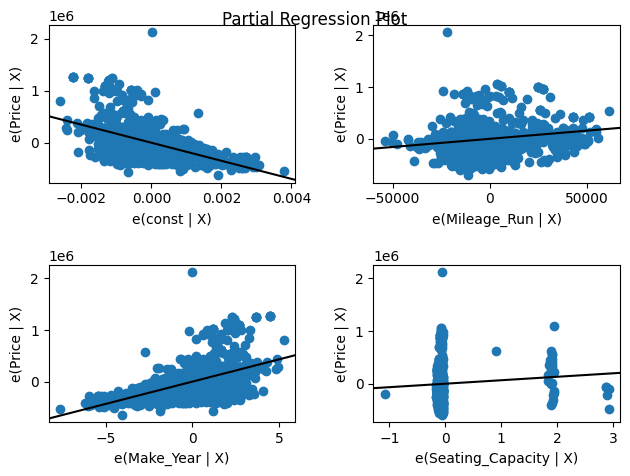

In [64]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.regressionplots import plot_partregress_grid

# Define the independent variables (including all numeric ones)
X = X_train[['Mileage_Run', 'Make_Year', 'Seating_Capacity']]
X = sm.add_constant(X)  # Add intercept term

# Define the dependent variable
y = y_train

# Fit the regression model using statsmodels
model = sm.OLS(y, X).fit()

# Create partial regression plots
fig = plot_partregress_grid(model)
plt.show()


* Weak positive relationship between the residuals of Price and the residuals of Mileage_Run. Looks reasonably linear.
* Clear positive relationship between residuals of Make_Year  and residuals of Price. Looks reasonably linear.
* Seating capacity does not seem to have a lot of predictive power, not sure if linear in part because it is discrete variable.

6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Make               976 non-null    object
 1   Make_Year          976 non-null    int64 
 2   Color              976 non-null    object
 3   Body_Type          976 non-null    object
 4   Mileage_Run        976 non-null    int64 
 5   No_of_Owners       976 non-null    object
 6   Seating_Capacity   976 non-null    int64 
 7   Fuel_Type          976 non-null    object
 8   Transmission       976 non-null    object
 9   Transmission_Type  976 non-null    object
 10  Price              976 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 84.0+ KB


In [66]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Apply IHS transformation to Mileage_Run
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

X_train_transformed['Mileage_Run'] = np.arcsinh(X_train['Mileage_Run'])
X_test_transformed['Mileage_Run'] = np.arcsinh(X_test['Mileage_Run'])

# Model 3: Using transformed Mileage_Run with all features
model3 = LinearRegression()
model3.fit(X_train_transformed, y_train)

# Predictions for Model 3
y_train_pred3 = model3.predict(X_train_transformed)
y_test_pred3 = model3.predict(X_test_transformed)

# Evaluation Metrics for Model 3
rmse_train_m3 = np.sqrt(mean_squared_error(y_train, y_train_pred3))
r2_train_m3 = r2_score(y_train, y_train_pred3)
rmse_test_m3 = np.sqrt(mean_squared_error(y_test, y_test_pred3))
r2_test_m3 = r2_score(y_test, y_test_pred3)

print("\nModel 3 (All features, IHS-transformed Mileage_Run):")
print("Train RMSE:", rmse_train_m3)
print("Train R2:", r2_train_m3)
print("Test RMSE:", rmse_test_m3)
print("Test R2:", r2_test_m3)



Model 3 (All features, IHS-transformed Mileage_Run):
Train RMSE: 142439.6994970254
Train R2: 0.8546426334246162
Test RMSE: 143687.2621202233
Test R2: 0.8199926550704686


* this model has highest R2 and RMSE compared to simpler models.

In [68]:
# Add interaction term: IHS-transformed Mileage_Run × Make_Year
X_train_transformed['Mileage_MakeYear_interaction'] = X_train_transformed['Mileage_Run'] * X_train_transformed['Make_Year']
X_test_transformed['Mileage_MakeYear_interaction'] = X_test_transformed['Mileage_Run'] * X_test_transformed['Make_Year']

# Model 3: Using transformed Mileage_Run with all features + interaction term
model3 = LinearRegression()
model3.fit(X_train_transformed, y_train)

# Predictions for Model 3
y_train_pred3 = model3.predict(X_train_transformed)
y_test_pred3 = model3.predict(X_test_transformed)

# Evaluation Metrics for Model 3
rmse_train_m3 = np.sqrt(mean_squared_error(y_train, y_train_pred3))
r2_train_m3 = r2_score(y_train, y_train_pred3)
rmse_test_m3 = np.sqrt(mean_squared_error(y_test, y_test_pred3))
r2_test_m3 = r2_score(y_test, y_test_pred3)

print("\nModel 3 (All features, IHS-transformed Mileage_Run + Interaction):")
print("Train RMSE:", rmse_train_m3)
print("Train R2:", r2_train_m3)
print("Test RMSE:", rmse_test_m3)
print("Test R2:", r2_test_m3)



Model 3 (All features, IHS-transformed Mileage_Run + Interaction):
Train RMSE: 141668.9272604496
Train R2: 0.8562114979123312
Test RMSE: 143384.04248653393
Test R2: 0.8207515834420441


7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?

The more complex not always the better. For example, when I merely added Seating Capacity in the simple models, my R2 went down. My more complex model had much higher R2. However, something to consider with more compelx R2 is there could be some overfitting. For example, test R2 is much lower than train R2.






8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.